# 観測カテゴリを用いたlatent-MNAR候補モデルの検証

## tl;dr
このnotebookは、`notes/reading/latent_mnar_observed_category_identification_candidate.md`
の**追加仮定を含む候補モデル**を対象にする。旧block bridgeの再実行ではない。

- DGPは $W,Z\to F\to Y_j$、$(Y_1,Y_j)\to D_j$。$Z\to Y_j$ の直接辺は置かない。
- 母集団の観測テンソルのみからのmatrix-pencil分解・逆算は検算を通過する。
  各三方向行列のKruskal rankは2。ただし旧4セルblockのcompletenessは成立しない。
- MNARのbias補正と、MCAR/MARにおける分散増大を比較する。
  **点識別と安定した区間推定は別問題**なので、境界解・CI作成失敗も必ず併記する。
- 本稿・スライドの数値は変更しない。以下の結果は今回の新DGPから再計算したもの。


## Context & Methods

### Key Assumptions
$X$は固定、$V=(W,Z)$は4カテゴリ、$F$は1因子・2クラス。
$Y_1$は常時観測、$Y_2,Y_3$は二値で欠測あり。

$$p(v,f,y,d)=p(v)p(f\mid v)\prod_{j=1}^3M_j(y_j,f)
\prod_{j=2}^3\pi_j(y_1,y_j)^{d_j}\{1-\pi_j(y_1,y_j)\}^{1-d_j}.$$

$D_2,D_3$は$Y$を条件として独立。selectionは$F,W,Z$へ直接依存しない。
この追加制約は元の一般的Missing-IV exclusionより強い。
条件付き独立とpositivityからcomplete-case率は正になる。
**complete caseが存在しない設計はこの検証の対象外。**

三方向分解の代数表現で使う$G=P(V\mid F)$はBayesの公式によるもので、DAGの辺を逆転させない。
任意のblock lawの回復ではなく、共通測定核を課した観測尤度を同時に最大化する。
Allman et al. (2009)はモデル・テンソル分解の原典であり、今回の数値設定・Monte Carlo結果の出典ではない。

### 比較手法
1. **Complete-data oracle**: 欠測前の全Yを使う。Fは観測せず推定する。
2. **Ignorable FIML**: selectionを無視する。MCAR/MARでは正指定、MNARでは誤指定。
3. **Restricted selection (Yj only)**: 各Djの確率をYjだけの2セルに制限。
   MCARでは正指定、今回のMAR/MNARではY1依存を落とす誤指定。
4. **Candidate saturated / correct full-interaction logistic**:
   各$\pi_j(a,y)$を4セル自由に推定し、全観測パターンの共通潜在構造と同時推定する。

以前の「正指定selection likelihood」と「提案法」の2枠は、この候補では同じモデルになる。
$1,Y_1,Y_j,Y_1Y_j$の4係数logisticは4個の自由な応答確率と一対一対応するため、
同じ曲線を2本描かない。**旧bridge-weighted estimatorの頑健性や効率性の検証ではない。**

各方法に同じV情報を与える。真値を初期値には使わず、6個の乱数初期値から最小負対数尤度を選ぶ。
logitパラメータの計算上の範囲は[-10,10]。端に近い解は境界解と記録する。
クラスは$M_2(1,1)<M_2(1,2)$でそろえる。


In [1]:
from pathlib import Path
import sys, json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, FancyArrowPatch, Polygon
from IPython.display import display

root = Path.cwd()
if not (root / 'experiment.py').exists():
    root = root / 'simulation' / 'observed_category'
sys.path.insert(0, str(root))
import experiment as e
figures = root / 'figures'
figures.mkdir(exist_ok=True)
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 12})
METHODS = e.METHODS
LABELS = {'oracle':'Complete-data oracle', 'MAR_ignorability':'Ignorable FIML',
          'selection_misspecified':'Restricted selection (Yj only)',
          'candidate_saturated':'Candidate saturated (= correct logistic)'}
COLORS = dict(zip(METHODS, ['#525252','#2369bd','#cf6819','#18815c']))


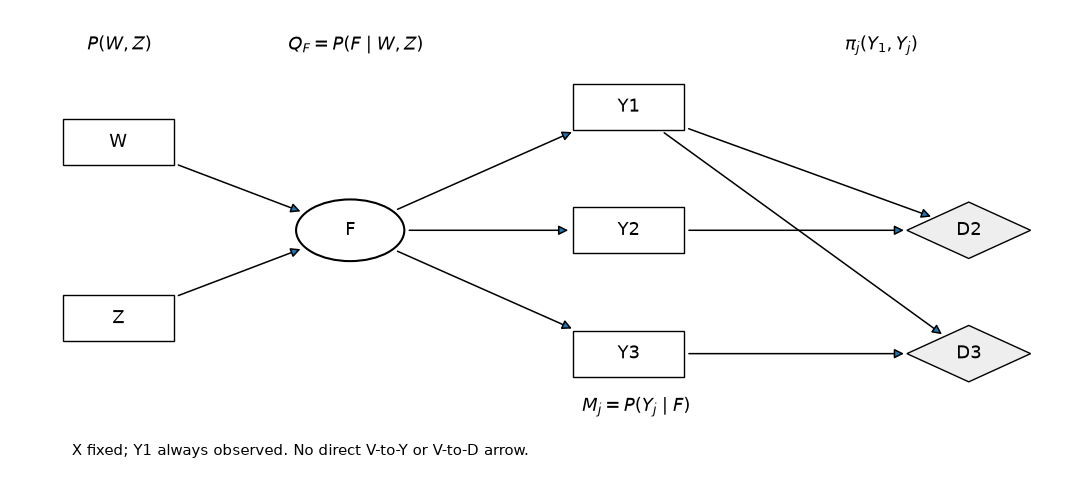

In [2]:
fig, ax = plt.subplots(figsize=(11, 5))
positions = {'W':(.5,2.5), 'Z':(.5,.5), 'F':(2,1.5),
             'Y1':(3.8,2.9), 'Y2':(3.8,1.5), 'Y3':(3.8,.1),
             'D2':(6,1.5), 'D3':(6,.1)}
nodes = {}
for name,(x,y) in positions.items():
    if name == 'F':
        shape = Circle((x,y), .35, facecolor='white', edgecolor='black', linewidth=1.5)
    elif name.startswith('D'):
        shape = Polygon([(x-.4,y),(x,y+.32),(x+.4,y),(x,y-.32)], facecolor='#eeeeee',edgecolor='black')
    else:
        shape = Rectangle((x-.36,y-.26),.72,.52,facecolor='white',edgecolor='black')
    ax.add_patch(shape)
    nodes[name] = shape
    ax.text(x,y,name,ha='center',va='center',fontsize=13)
edges = [('W','F'),('Z','F'),('F','Y1'),('F','Y2'),('F','Y3'),
         ('Y1','D2'),('Y1','D3'),('Y2','D2'),('Y3','D3')]
for a,b in edges:
    ax.add_patch(FancyArrowPatch(positions[a], positions[b],patchA=nodes[a],patchB=nodes[b],
                 arrowstyle='-|>',mutation_scale=14,linewidth=1.1,shrinkA=3,shrinkB=3))
ax.text(.3,3.55,r'$P(W,Z)$',fontsize=13)
ax.text(1.6,3.55,r'$Q_F=P(F\mid W,Z)$',fontsize=13)
ax.text(3.5,-.55,r'$M_j=P(Y_j\mid F)$',fontsize=13)
ax.text(5.2,3.55,r'$\pi_j(Y_1,Y_j)$',fontsize=13)
ax.text(.2,-1.05,'X fixed; Y1 always observed. No direct V-to-Y or V-to-D arrow.',fontsize=11)
ax.set(xlim=(-.2,6.7),ylim=(-1.3,4))
ax.axis('off')
fig.tight_layout()
fig.savefig(figures/'candidate_dag.png',dpi=160)
plt.show()


## Data
旧実験と同じn=500・100反復・6個の測定核・平均項目観測率80%を使用する。
安定性確認としてn=5,000も100反復実行する。各nでMCAR/MAR/MNARに同一の完全データと応答乱数を用いる。
比較手法間も同じ標本。oracleは真のクラスを知っている推定量ではない。

既定では保存済みMonte Carlo結果を読み込む。`RUN_MC=True`で全実験を再実行できる。
source hash・設定を照合し、結果を別DGPと混同しない。


In [3]:
RUN_MC = False
if RUN_MC:
    import subprocess
    for n, directory in [(500,'results'), (5000,'results_n5000')]:
        subprocess.run([sys.executable, str(root/'experiment.py'), '--sample-size',str(n),
                        '--output',directory], check=True)
summary, estimates, diagnostics = [], [], []
for n,directory in [(500,'results'), (5000,'results_n5000')]:
    path = root/directory
    provenance = json.loads((path/'provenance.json').read_text())
    assert provenance['source_sha256'] == hashlib.sha256((root/'experiment.py').read_bytes()).hexdigest()
    run_config = json.loads((path/'run_config.json').read_text())
    assert run_config['sample_size'] == n and run_config['replications'] == 100
    expected_config = e.config()
    expected_config['sample_size'] = n
    assert run_config == expected_config
    for container, filename in [(summary,'summary'),(estimates,'estimates'),(diagnostics,'diagnostics')]:
        container.append(pd.read_csv(path/(filename+'.csv')).assign(n=n))
summary, estimates, diagnostics = map(pd.concat,[summary,estimates,diagnostics])
assert len(estimates) == 2*3*100*4*len(e.NAMES)
display(pd.Series(e.config(), name='DGP / computation'))
display(pd.DataFrame([json.loads((root/d/'provenance.json').read_text()) for d in ['results','results_n5000']]))


seed                                                         260907
sample_size                                                     500
replications                                                    100
starts                                                            6
maxiter                                                        1500
workers                                                           4
mechanisms                                        [MCAR, MAR, MNAR]
v_states                           [[0, 0], [0, 1], [1, 0], [1, 1]]
v_probability                              [0.25, 0.25, 0.25, 0.25]
class2_given_v                                 [0.1, 0.3, 0.6, 0.8]
measurement                [[0.15, 0.8], [0.25, 0.75], [0.2, 0.85]]
nonanchor_response_rate                                         0.7
selection_coefficients                           [-0.5, -0.8, -1.2]
Name: DGP / computation, dtype: object

,python,numpy,scipy,pandas,source_sha256
0,3.13.14,2.5.2,1.18.1,3.0.5,a50300d7d007a4dfec9fa4fe4a21ba5e48005a8fb7460b...
1,3.13.14,2.5.2,1.18.1,3.0.5,a50300d7d007a4dfec9fa4fe4a21ba5e48005a8fb7460b...


### 識別条件と母集団での回復
各$Y_1=a$層で$P(T_2,T_3,V\mid Y_1=a)$を構成し、真のKやGを入力せずに
matrix pencilで分解する。その後$K_jr_j=1$から$\pi_j,M_j$を復元する。
スケールとlabelをそろえ、$G,p_f,M_1$の真値との一致も検算する。
このmatrix pencilは今回の投影で固有値が分離する数値検算であり、一般的な頑健テンソル推定器ではない。
標本推定には上記の同時尤度を使う。


In [4]:
checks = pd.DataFrame([r for mechanism in e.config()['mechanisms'] for r in e.population_checks(e.config(), mechanism)])
display(checks.round(6))
print('Population tensor decomposition / inversion: passed (absolute error < 1e-9).')
print('Kruskal: 2+2+2 = 6 = 2r+2, r=2. Old four-cell block rank: 2, not 4.')


,mechanism,stratum,matrix,rank,sigma_min,inverse_determinant
0,MCAR,0,K2,2,0.350000,0.245000
1,MCAR,0,K3,2,0.454400,0.318500
2,MCAR,1,K2,2,0.350000,0.245000
3,MCAR,1,K3,2,0.454400,0.318500
4,MCAR,both,G,2,0.383831,NaN
5,MCAR,fixed X,old_pair_12,2,0.000000,NaN
6,MCAR,fixed X,old_pair_13,2,0.000000,NaN
7,MAR,0,K2,2,0.373319,0.278734
8,MAR,0,K3,2,0.484566,0.362354
9,MAR,1,K2,2,0.320621,0.205596


Population tensor decomposition / inversion: passed (absolute error < 1e-9).
Kruskal: 2+2+2 = 6 = 2r+2, r=2. Old four-cell block rank: 2, not 4.


## Results

### 指標と区間の扱い
$M_j$は$P(Y_j=1\mid F=f)$、$p_f$はクラス2比率、$\mu_j=E(Y_j)$。
全joint lawの8セル確率も評価する。biasとRMSE・SDは**全100反復**で計算。

推定SEは、常時観測Vの経験分布の推定誤差も含むsandwich・delta法。
収束不良、境界解、Hessianの非正定値ではWald CIを作らない。
**coverage_validはCIが計算できた反復内のみの条件付きcoverageであり、100反復全体のcoverageではない。**
平均SEとの比較には同じ有効反復のSD_validも使う。CI_failure_rateとvalid_CIを別表で示す。
`covered_and_available`は「CIを作成でき、かつ真値を含む」割合であり、通常のcoverageとは呼ばない。


In [5]:
quality = diagnostics.groupby(['n','mechanism','method']).agg(
    convergence=('stationary','mean'), boundary_rate=('boundary','mean'),
    CI_available=('valid_se','mean'), item_rate=('item_rate','mean'), complete_rate=('complete_rate','mean'))
display(quality.round(4))
selected = summary[summary.parameter.isin(['M2_class2','M3_class2','p_class2','mean_Y2','mean_Y3'])]
display(selected.round(4).reset_index(drop=True))


convergence  boundary_rate  \
n    mechanism method                                               
500  MAR       MAR_ignorability                1.0           0.03   
               candidate_saturated             1.0           0.29   
               oracle                          1.0           0.00   
               selection_misspecified          1.0           0.04   
     MCAR      MAR_ignorability                1.0           0.03   
               candidate_saturated             1.0           0.30   
               oracle                          1.0           0.00   
               selection_misspecified          1.0           0.03   
     MNAR      MAR_ignorability                1.0           0.22   
               candidate_saturated             1.0           0.41   
               oracle                          1.0           0.00   
               selection_misspecified          1.0           1.00   
5000 MAR       MAR_ignorability                1.0           0.00   
               candidate_saturated             1.0           0.00   
               oracle                          1.0           0.00   
               selection_misspecified          1.0           0.00   
     MCAR      MAR_ignorability                1.0           0.00   
               candidate_saturated             1.0           0.00   
               oracle                          1.0           0.00   
               selection_misspecified          1.0           0.00   
     MNAR      MAR_ignorability                1.0           0.00   
               candidate_saturated             1.0           0.00   
               oracle                          1.0           0.00   
               selection_misspecified          1.0           1.00   

                                       CI_available  item_rate  complete_rate  
n    mechanism method                                                          
500  MAR       MAR_ignorability                0.97     0.7996         0.4927  
               candidate_saturated             0.71     0.7996         0.4927  
               oracle                          1.00     0.7996         0.4927  
               selection_misspecified          0.96     0.7996         0.4927  
     MCAR      MAR_ignorability                0.97     0.7999         0.4903  
               candidate_saturated             0.70     0.7999         0.4903  
               oracle                          1.00     0.7999         0.4903  
               selection_misspecified          0.97     0.7999         0.4903  
     MNAR      MAR_ignorability                0.78     0.8003         0.5228  
               candidate_saturated             0.59     0.8003         0.5228  
               oracle                          1.00     0.8003         0.5228  
               selection_misspecified          0.00     0.8003         0.5228  
5000 MAR       MAR_ignorability                1.00     0.8003         0.4934  
               candidate_saturated             1.00     0.8003         0.4934  
               oracle                          1.00     0.8003         0.4934  
               selection_misspecified          1.00     0.8003         0.4934  
     MCAR      MAR_ignorability                1.00     0.8005         0.4912  
               candidate_saturated             1.00     0.8005         0.4912  
               oracle                          1.00     0.8005         0.4912  
               selection_misspecified          1.00     0.8005         0.4912  
     MNAR      MAR_ignorability                1.00     0.8000         0.5214  
               candidate_saturated             1.00     0.8000         0.5214  
               oracle                          1.00     0.8000         0.5214  
               selection_misspecified          0.00     0.8000         0.5214

,mechanism,method,parameter,bias,RMSE,SD,estimated_SE,coverage_valid,valid_CI,SD_valid,CI_failure_rate,covered_and_available,bias_MCSE,replications,n
0,MAR,MAR_ignorability,M2_class2,-0.0011,0.0435,0.0437,0.0482,0.9691,97,0.0422,0.03,0.94,0.0044,100,500
1,MAR,MAR_ignorability,M3_class2,-0.0044,0.0500,0.0500,0.0466,0.9278,97,0.0489,0.03,0.90,0.0050,100,500
2,MAR,MAR_ignorability,mean_Y2,0.0004,0.0255,0.0257,0.0261,0.9278,97,0.0259,0.03,0.90,0.0026,100,500
3,MAR,MAR_ignorability,mean_Y3,0.0004,0.0233,0.0234,0.0257,0.9794,97,0.0237,0.03,0.95,0.0023,100,500
4,MAR,MAR_ignorability,p_class2,0.0011,0.0455,0.0457,0.0447,0.9691,97,0.0423,0.03,0.94,0.0046,100,500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,MNAR,selection_misspecified,M2_class2,0.0423,0.0436,0.0105,NaN,NaN,0,NaN,1.00,0.00,0.0010,100,5000
116,MNAR,selection_misspecified,M3_class2,0.0220,0.0244,0.0106,NaN,NaN,0,NaN,1.00,0.00,0.0011,100,5000
117,MNAR,selection_misspecified,mean_Y2,0.0727,0.0731,0.0070,NaN,NaN,0,NaN,1.00,0.00,0.0007,100,5000
118,MNAR,selection_misspecified,mean_Y3,0.0656,0.0660,0.0076,NaN,NaN,0,NaN,1.00,0.00,0.0008,100,5000


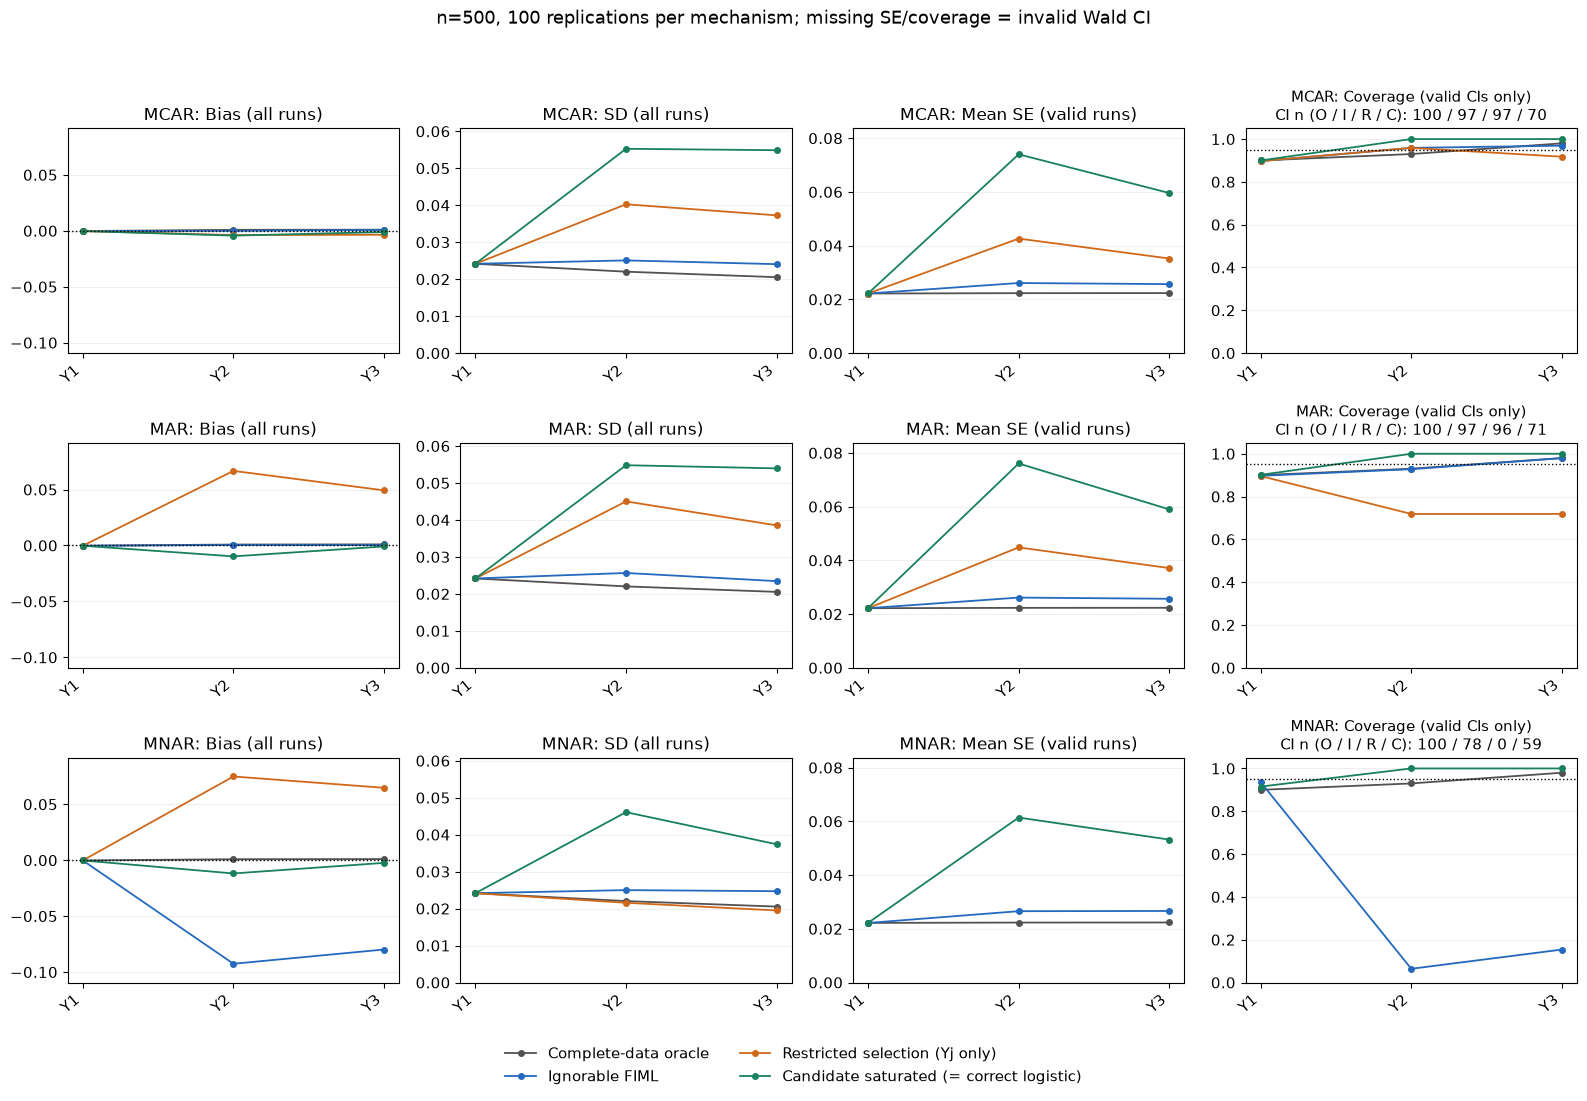

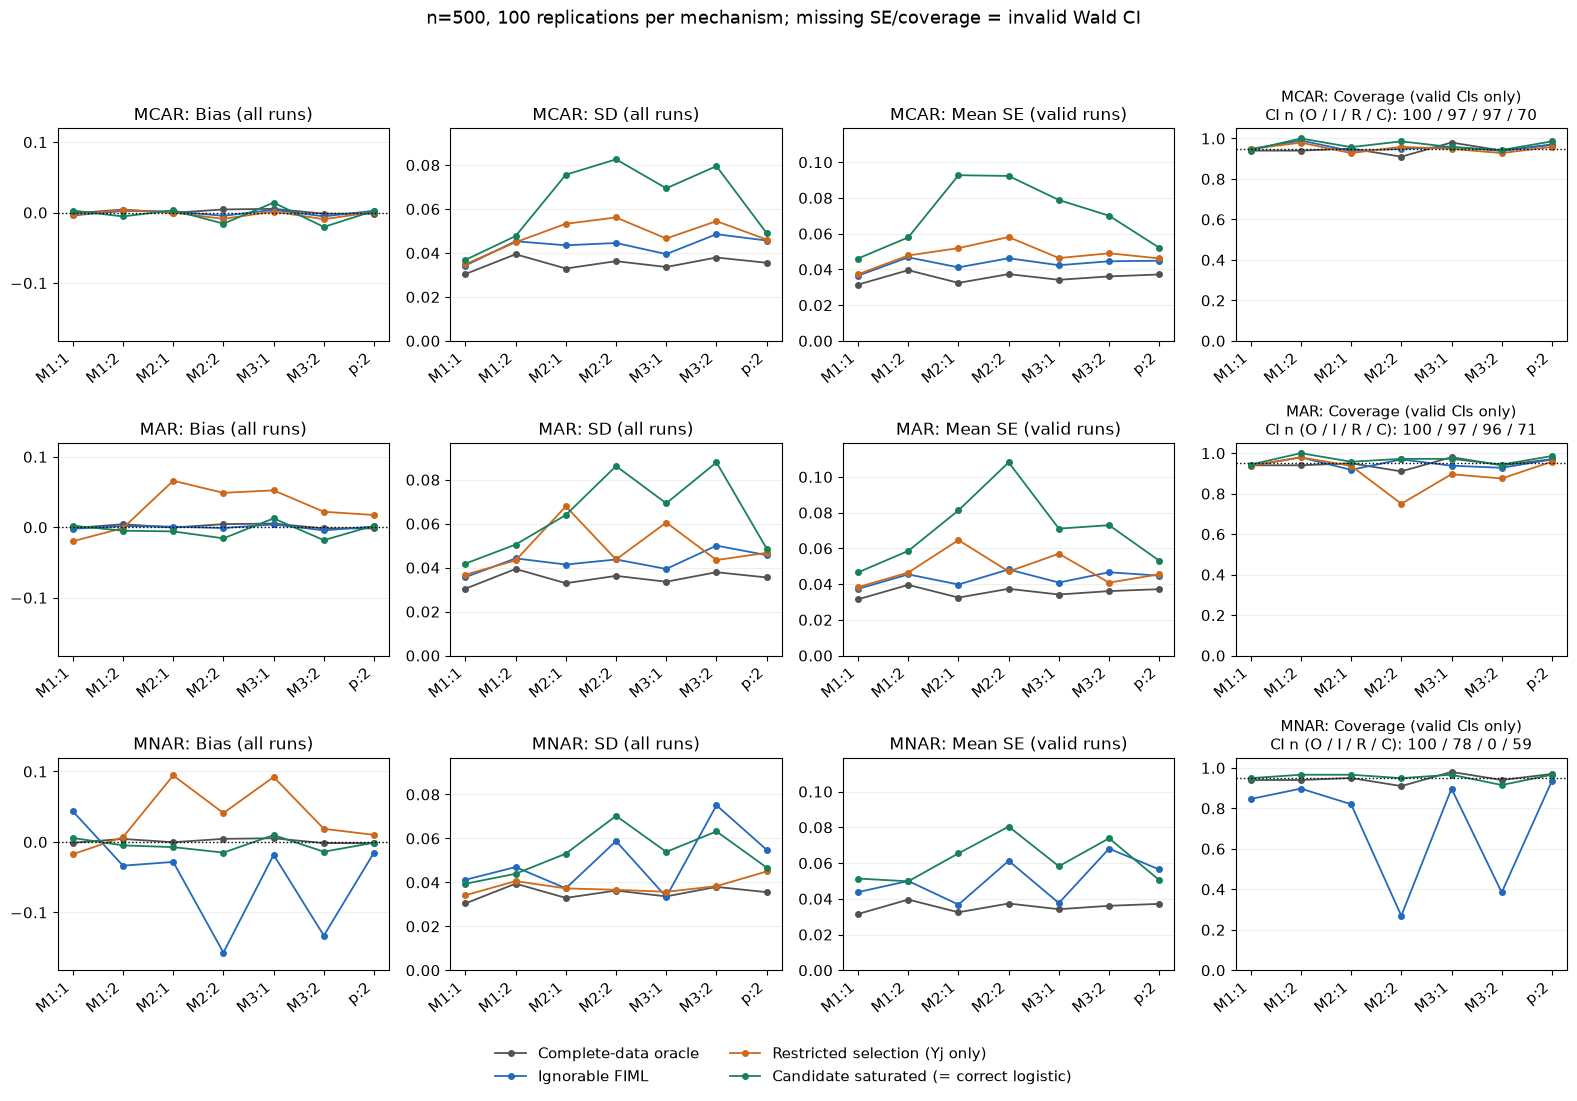

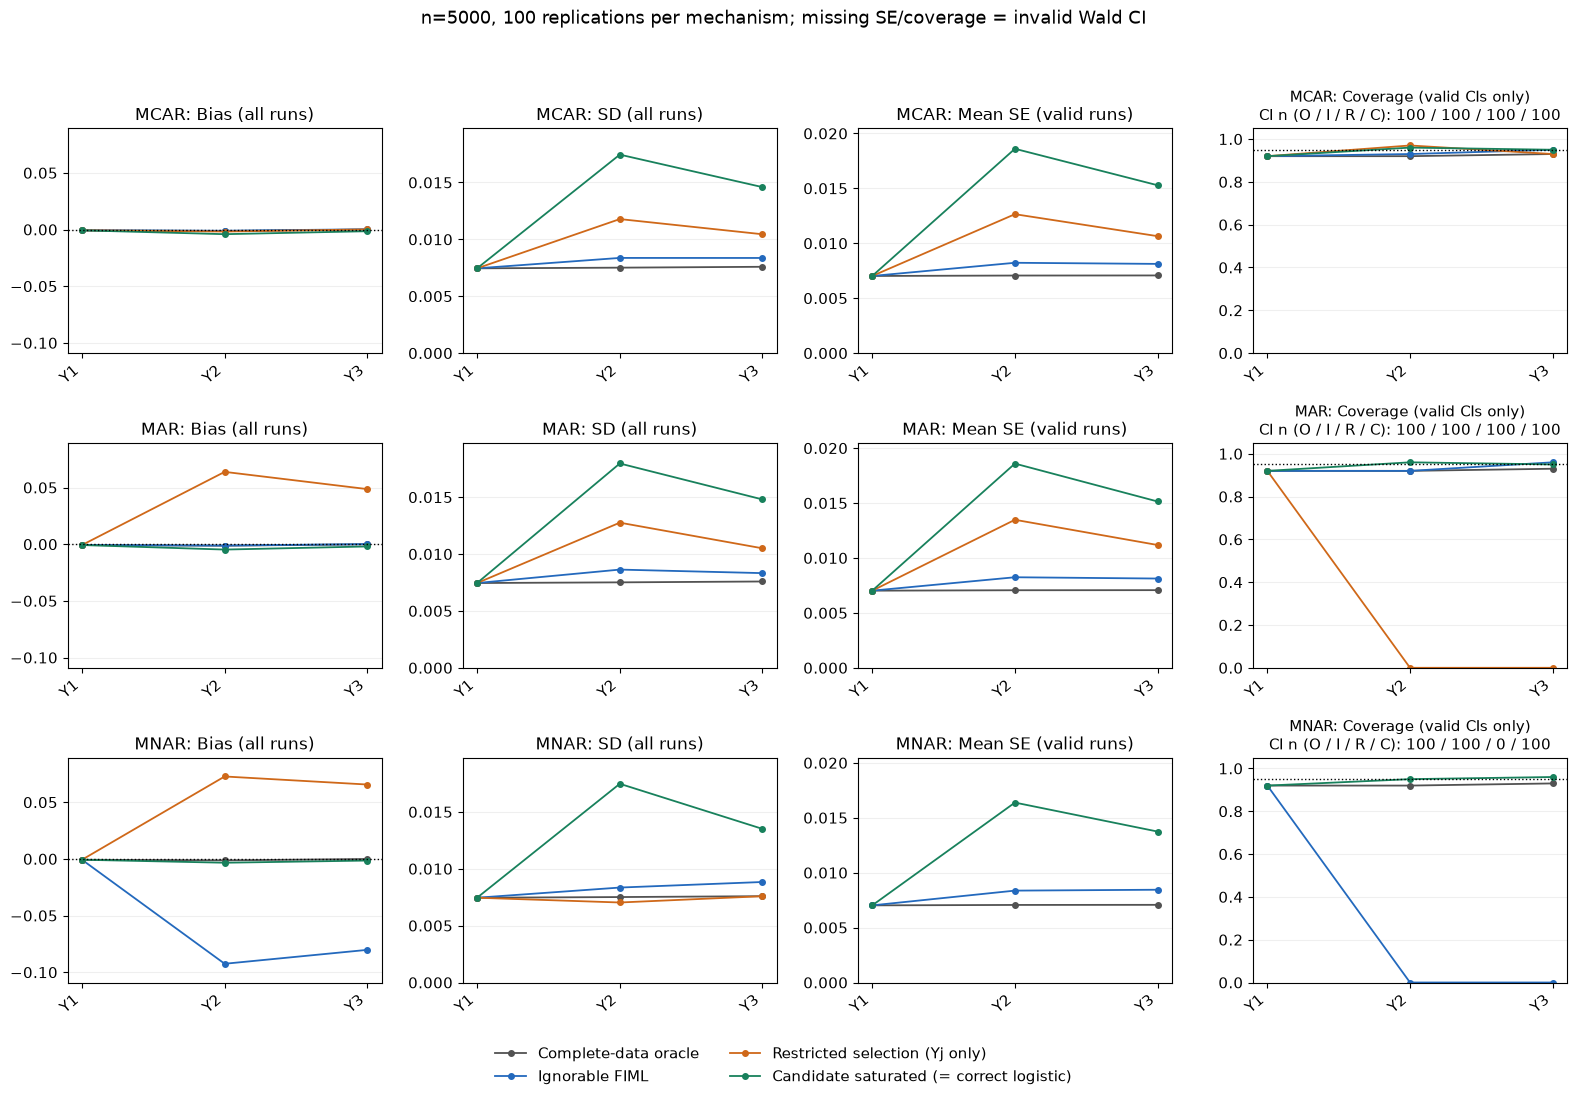

In [6]:
def criteria_plot(parameters, filename, n=500):
    fig, axes = plt.subplots(3,4,figsize=(16,11),squeeze=False,sharey='col')
    criteria = [('bias','Bias (all runs)'),('SD','SD (all runs)'),
                ('estimated_SE','Mean SE (valid runs)'),('coverage_valid','Coverage (valid CIs only)')]
    for i, mechanism in enumerate(['MCAR','MAR','MNAR']):
        for k,(column,title) in enumerate(criteria):
            ax = axes[i,k]
            for method in METHODS:
                g = summary[(summary.n==n)&(summary.mechanism==mechanism)&(summary.method==method)].set_index('parameter').loc[parameters]
                ax.plot(range(len(parameters)),g[column],marker='o',ms=4,lw=1.3,color=COLORS[method],label=LABELS[method])
            ax.set_xticks(range(len(parameters)), [p.replace('mean_','').replace('_class',':') for p in parameters],rotation=40,ha='right')
            ax.set_title(f'{mechanism}: {title}')
            ax.grid(axis='y',alpha=.2)
            if column == 'bias': ax.axhline(0,color='black',ls=':',lw=1)
            elif column == 'coverage_valid':
                ax.axhline(.95,color='black',ls=':',lw=1)
                ax.set_ylim(0,1.05)
                valid = [int(summary[(summary.n==n)&(summary.mechanism==mechanism)&
                         (summary.method==m)].valid_CI.iloc[0]) for m in METHODS]
                ax.set_title(f'{mechanism}: {title}\nCI n (O / I / R / C): '+ ' / '.join(map(str,valid)),fontsize=11)
    plot_data = summary[(summary.n==n)&summary.parameter.isin(parameters)]
    for k,(column,_) in enumerate(criteria):
        if column != 'coverage_valid':
            low = min(0,plot_data[column].min()) if column == 'bias' else 0
            high = max(0,plot_data[column].max())
            margin = max((high-low)*.1, .001)
            axes[0,k].set_ylim(low-margin if column == 'bias' else 0, high+margin)
    handles, labels = axes[0,0].get_legend_handles_labels()
    fig.legend(handles,labels,loc='lower center',ncol=2,bbox_to_anchor=(.5,.005),frameon=False)
    fig.suptitle(f'n={n}, 100 replications per mechanism; missing SE/coverage = invalid Wald CI',y=.995)
    fig.tight_layout(rect=(0,.065,1,.97))
    fig.savefig(figures/filename,dpi=150)
    plt.show()
criteria_plot(['mean_Y1','mean_Y2','mean_Y3'],'outcome_criteria_n500.png')
criteria_plot(e.NAMES[:7],'latent_criteria_n500.png')
criteria_plot(['mean_Y1','mean_Y2','mean_Y3'],'outcome_criteria_n5000.png',n=5000)


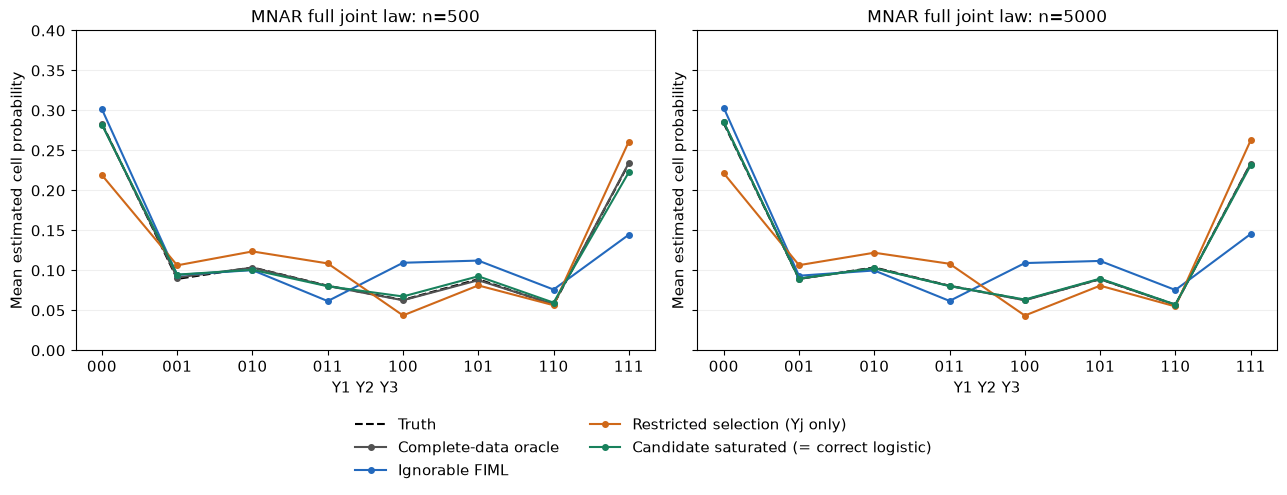

In [7]:
fig, axes = plt.subplots(1,2,figsize=(13,5),sharey=True)
for ax,n in zip(axes,[500,5000]):
    subset = estimates[(estimates.n==n)&(estimates.mechanism=='MNAR')&estimates.parameter.str.startswith('P')]
    parameters = e.NAMES[-8:]
    true = subset.groupby('parameter').truth.first().reindex(parameters)
    ax.plot(range(8),true,color='black',ls='--',lw=1.5,label='Truth')
    for method in METHODS:
        values = subset[subset.method==method].groupby('parameter').estimate.mean().reindex(parameters)
        ax.plot(range(8),values,color=COLORS[method],marker='o',ms=4,label=LABELS[method])
    ax.set_xticks(range(8),[p[1:] for p in parameters])
    ax.set(xlabel='Y1 Y2 Y3',ylabel='Mean estimated cell probability',title=f'MNAR full joint law: n={n}',ylim=(0,.4))
    ax.grid(axis='y',alpha=.2)
handles,labels=axes[0].get_legend_handles_labels()
fig.legend(handles,labels,loc='lower center',ncol=2,bbox_to_anchor=(.5,0),frameon=False)
fig.tight_layout(rect=(0,.16,1,1))
fig.savefig(figures/'full_joint_recovery.png',dpi=160)
plt.show()


## Takeaways
以下は実行結果から自動集計する。平均biasだけでなくRMSEと境界解も確認する。
100反復のcoverageはMonte Carlo誤差も大きいため、名目95%達成を断定しない。


In [8]:
compact=[]
for (n,mechanism,method),g in summary.groupby(['n','mechanism','method']):
    measurement=g[g.parameter.str.startswith('M')]
    pf=g[g.parameter=='p_class2'].iloc[0]
    compact.append(dict(n=n,mechanism=mechanism,method=LABELS[method],
                        mean_abs_M_bias=measurement.bias.abs().mean(),
                        mean_component_M_RMSE=measurement.RMSE.mean(),
                        pf_bias=pf.bias,pf_RMSE=pf.RMSE,CI_failure=pf.CI_failure_rate))
compact=pd.DataFrame(compact)
compact.to_csv(root/'comparison_summary.csv',index=False)
display(compact.round(4))
for n in [500,5000]:
    g=summary[(summary.n==n)&(summary.mechanism=='MNAR')]
    for p in ['mean_Y2','mean_Y3','M2_class2','M3_class2','p_class2']:
        h=g[g.parameter==p].set_index('method')
        print(f"n={n}, {p}: bias {h.loc['MAR_ignorability','bias']:+.4f} (ignorable) -> "
              f"{h.loc['candidate_saturated','bias']:+.4f} (candidate); "
              f"candidate valid CIs {int(h.loc['candidate_saturated','valid_CI'])}/100")


,n,mechanism,method,mean_abs_M_bias,mean_component_M_RMSE,pf_bias,pf_RMSE,CI_failure
0,500,MAR,Ignorable FIML,0.0024,0.0423,0.0011,0.0455,0.03
1,500,MAR,Candidate saturated (= correct logistic),0.0099,0.0671,0.0023,0.0485,0.29
2,500,MAR,Complete-data oracle,0.0029,0.0351,-0.0016,0.0354,0.00
3,500,MAR,Restricted selection (Yj only),0.0350,0.0622,0.0174,0.0497,0.04
4,500,MCAR,Ignorable FIML,0.0037,0.0426,0.0025,0.0455,0.03
5,500,MCAR,Candidate saturated (= correct logistic),0.0103,0.0660,0.0023,0.0488,0.30
6,500,MCAR,Complete-data oracle,0.0029,0.0351,-0.0016,0.0354,0.00
7,500,MCAR,Restricted selection (Yj only),0.0044,0.0484,0.0008,0.0459,0.03
8,500,MNAR,Ignorable FIML,0.0690,0.0870,-0.0150,0.0566,0.22
9,500,MNAR,Candidate saturated (= correct logistic),0.0094,0.0545,-0.0011,0.0465,0.41


n=500, mean_Y2: bias -0.0926 (ignorable) -> -0.0118 (candidate); candidate valid CIs 59/100
n=500, mean_Y3: bias -0.0798 (ignorable) -> -0.0024 (candidate); candidate valid CIs 59/100
n=500, M2_class2: bias -0.1570 (ignorable) -> -0.0151 (candidate); candidate valid CIs 59/100
n=500, M3_class2: bias -0.1329 (ignorable) -> -0.0138 (candidate); candidate valid CIs 59/100
n=500, p_class2: bias -0.0150 (ignorable) -> -0.0011 (candidate); candidate valid CIs 59/100
n=5000, mean_Y2: bias -0.0925 (ignorable) -> -0.0034 (candidate); candidate valid CIs 100/100
n=5000, mean_Y3: bias -0.0802 (ignorable) -> -0.0015 (candidate); candidate valid CIs 100/100
n=5000, M2_class2: bias -0.1555 (ignorable) -> -0.0037 (candidate); candidate valid CIs 100/100
n=5000, M3_class2: bias -0.1311 (ignorable) -> -0.0031 (candidate); candidate valid CIs 100/100
n=5000, p_class2: bias -0.0173 (ignorable) -> +0.0005 (candidate); candidate valid CIs 100/100


### 解釈の限界
- rank条件が成立することと、n=500でWald推論が安定することは同じではない。
- 境界解を削除してbiasを改善した結果ではない。点推定には全反復を含める。
- selectionをセルごとに推定するが、測定族・クラス数・応答の条件付き独立・直接効果exclusionは指定している。
  これらの誤指定に対する頑健性を確認した実験ではない。
- 正指定のfull-interaction logisticと候補法は同じモデルなので、両者間の優位性は主張できない。
- 6初期値での数値最適化は大域的最適解の証明ではない。初期値間の目的関数差はdiagnostics.csvに記録する。
- 新規性・漸近理論・境界を扱う区間推定は未確認。このnotebookの良否だけで原稿の定理を置き換えない。
